# byteSmart Testing and Inference Notebook

This notebook loads the three saved pickle models and uses the test data for predictions. It does not retrain the models.

## 1. Setup

In [19]:
# Keep the library list small and focused.
import pickle
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        ConfusionMatrixDisplay,
        mean_absolute_error,
        mean_squared_error,
        r2_score,
        silhouette_score,
    )
except ImportError:
    %pip -q install scikit-learn
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        ConfusionMatrixDisplay,
        mean_absolute_error,
        mean_squared_error,
        r2_score,
        silhouette_score,
    )

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', exc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load the Saved Models

In [20]:
MODEL_NAMES = [
    'linear_regression_model.pkl',
    'logistic_regression_model.pkl',
    'kmeans_model.pkl',
]
MODEL_SEARCH_ROOTS = [
    Path('/content'),
    Path('/content/drive/MyDrive'),
    Path.cwd(),
    Path('/Users/mokshjoshi/Documents/Internship/byteSmart_colab_files'),
]

def find_file(file_name, roots=MODEL_SEARCH_ROOTS):
    for root in roots:
        if root.exists():
            direct = root / file_name
            if direct.exists():
                return direct
            matches = list(root.rglob(file_name))
            if matches:
                return matches[0]
    raise FileNotFoundError(f'Could not find {file_name}. Upload it to Colab or place it in Google Drive.')

loaded_models = {}
for model_name in MODEL_NAMES:
    model_path = find_file(model_name)
    with open(model_path, 'rb') as f:
        loaded_models[model_name] = pickle.load(f)
    print('Loaded:', model_path)

Loaded: /content/drive/MyDrive/linear_regression_model.pkl
Loaded: /content/drive/MyDrive/logistic_regression_model.pkl
Loaded: /content/drive/MyDrive/kmeans_model.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.9.0 when using version 1.6.1. This might lead to breaking code or in

## 3. Load Zip Data

In [21]:
ZIP_NAME = '14888121-20260708T173347Z-3-001.zip'
SEARCH_ROOTS = [
    Path('/content'),
    Path('/content/drive/MyDrive'),
    Path.cwd(),
    Path('/Users/mokshjoshi/Downloads'),  # Allows local Mac verification.
]

def find_zip(zip_name=ZIP_NAME):
    for root in SEARCH_ROOTS:
        if root.exists():
            direct = root / zip_name
            if direct.exists():
                return direct
            matches = list(root.rglob(zip_name))
            if matches:
                return matches[0]
    raise FileNotFoundError(
        f'Could not find {zip_name}. Upload it into Colab or place it in Google Drive.'
    )

zip_path = find_zip()
extract_dir = Path('/content/byteSmart_data') if Path('/content').exists() else Path.cwd() / 'byteSmart_data'
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

data_dir = extract_dir / '14888121'
print('Using data directory:', data_dir)
print('CSV files:', [p.name for p in data_dir.glob('*.csv')])

Using data directory: /content/byteSmart_data/14888121
CSV files: ['Test1_TempCO2O2.csv', 'Test1_DryIceWeight.csv', 'Test2_TempCO2O2.csv']


## 4. Prepare Data

In [22]:
def elapsed_to_hours(series):
    td = pd.to_timedelta(series.astype(str), errors='coerce')
    return td.dt.total_seconds() / 3600

def load_dry_ice(path):
    raw = pd.read_csv(path, header=None)
    return pd.DataFrame({
        'hours': pd.to_numeric(raw.iloc[4:, 2], errors='coerce'),
        'baseline_lb': pd.to_numeric(raw.iloc[4:, 5], errors='coerce'),
        'refrigerated_lb': pd.to_numeric(raw.iloc[4:, 6], errors='coerce'),
    }).dropna(subset=['hours'])

def load_test1(path):
    df = pd.read_csv(path, low_memory=False).iloc[2:].copy()
    df['hours'] = elapsed_to_hours(df['Time Elapsed'])
    for col in df.columns:
        if col not in ['date', 'time', 'Time Elapsed', 'hours']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['hours'])

def load_test2(path):
    df = pd.read_csv(path, low_memory=False).iloc[1:].copy()
    df['timestamp'] = pd.to_datetime(df['TIMESTAMP'], errors='coerce')
    df['hours'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 3600
    for col in df.columns:
        if col not in ['TIMESTAMP', 'timestamp', 'hours']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['hours'])

def temperature_columns(df, exclude):
    return [
        col for col in df.columns
        if col not in exclude and pd.api.types.is_numeric_dtype(df[col]) and df[col].notna().sum() > 100
    ]

def sensor_slopes(df, cols):
    slopes = {}
    for col in cols:
        sub = df[['hours', col]].dropna()
        if len(sub) >= 2:
            slopes[col] = LinearRegression().fit(sub[['hours']], sub[col]).coef_[0]
    return pd.Series(slopes)

def make_windows(df, temp_cols, label, window_size=60):
    rows = []
    work = df[['hours', 'O2', 'CO2']].copy()
    work['mean_temp_F'] = df[temp_cols].mean(axis=1)
    work['spread_F'] = df[temp_cols].max(axis=1) - df[temp_cols].min(axis=1)
    work = work.dropna()

    for start in range(0, len(work) - window_size + 1, window_size):
        chunk = work.iloc[start:start + window_size]
        slope = LinearRegression().fit(chunk[['hours']], chunk['mean_temp_F']).coef_[0]
        rows.append({
            'label': label,
            'mean_temp_F': chunk['mean_temp_F'].mean(),
            'spread_F': chunk['spread_F'].mean(),
            'O2_mean': chunk['O2'].mean(),
            'CO2_mean': chunk['CO2'].mean(),
            'mean_temp_slope_F_per_hour': slope,
        })
    return pd.DataFrame(rows)

def sensor_feature_table(df, temp_cols, test_label):
    slopes = sensor_slopes(df, temp_cols)
    return pd.DataFrame({
        'sensor': temp_cols,
        'test': test_label,
        'mean_F': [df[c].mean() for c in temp_cols],
        'std_F': [df[c].std() for c in temp_cols],
        'min_F': [df[c].min() for c in temp_cols],
        'max_F': [df[c].max() for c in temp_cols],
        'slope_F_per_hour': [slopes.get(c, np.nan) for c in temp_cols],
    }).dropna()

dry = load_dry_ice(data_dir / 'Test1_DryIceWeight.csv')
test1 = load_test1(data_dir / 'Test1_TempCO2O2.csv')
test2 = load_test2(data_dir / 'Test2_TempCO2O2.csv')

test1_temp_cols = temperature_columns(
    test1, {'date', 'time', 'Time Elapsed', 'hours', 'O2', 'CO2', 'Ambient', 'Unnamed: 63', 'Unnamed: 64'}
)
test2_temp_cols = temperature_columns(
    test2, {'TIMESTAMP', 'timestamp', 'hours', 'O2', 'CO2'}
)

print('Dry ice rows:', dry.shape)
print('Test 1 rows and temperature sensors:', test1.shape, len(test1_temp_cols))
print('Test 2 rows and temperature sensors:', test2.shape, len(test2_temp_cols))

Dry ice rows: (108, 3)
Test 1 rows and temperature sensors: (112267, 66) 57
Test 2 rows and temperature sensors: (13944, 79) 74


## 5. Recreate the Same Test Splits

In [23]:
# Linear Regression dataset: predict dry ice mass from hours and condition.
dry_long = pd.concat([
    dry[['hours', 'baseline_lb']].rename(columns={'baseline_lb': 'mass_lb'}).assign(condition='baseline'),
    dry[['hours', 'refrigerated_lb']].rename(columns={'refrigerated_lb': 'mass_lb'}).assign(condition='refrigerated'),
], ignore_index=True).dropna()
dry_long['is_refrigerated'] = (dry_long['condition'] == 'refrigerated').astype(int)
linear_features = ['hours', 'is_refrigerated']

# Logistic Regression dataset: classify whether a time window looks like Test 1 or Test 2.
windows = pd.concat([
    make_windows(test1, test1_temp_cols, 'Test 1'),
    make_windows(test2, test2_temp_cols, 'Test 2'),
], ignore_index=True)
logistic_features = [
    'mean_temp_F',
    'spread_F',
    'O2_mean',
    'CO2_mean',
    'mean_temp_slope_F_per_hour',
]

# K-Means dataset: cluster sensor behavior based on summary statistics.
sensor_features = pd.concat([
    sensor_feature_table(test1, test1_temp_cols, 'Test 1'),
    sensor_feature_table(test2, test2_temp_cols, 'Test 2'),
], ignore_index=True)
kmeans_features = ['mean_F', 'std_F', 'min_F', 'max_F', 'slope_F_per_hour']

print('Linear Regression rows:', dry_long.shape)
print('Logistic Regression windows:', windows.shape)
print('K-Means sensor rows:', sensor_features.shape)

Linear Regression rows: (145, 4)
Logistic Regression windows: (2103, 6)
K-Means sensor rows: (131, 7)


In [24]:
X_linear = dry_long[linear_features]
y_linear = dry_long['mass_lb']
_, X_linear_test, _, y_linear_test = train_test_split(X_linear, y_linear, test_size=0.25, random_state=42)

X_logistic = windows[logistic_features]
y_logistic = windows['label']
_, X_logistic_test, _, y_logistic_test = train_test_split(
    X_logistic, y_logistic, test_size=0.25, random_state=42, stratify=y_logistic
)

X_kmeans = sensor_features[kmeans_features]
_, X_kmeans_test = train_test_split(X_kmeans, test_size=0.25, random_state=42)

## 6. Run Testing and Inference

In [25]:
# Linear Regression inference on test data.
linear_bundle = loaded_models['linear_regression_model.pkl']
loaded_linear_model = linear_bundle['model']
linear_loaded_predictions = loaded_linear_model.predict(X_linear_test[linear_bundle['features']])
print('Linear Regression loaded-model MAE:', round(mean_absolute_error(y_linear_test, linear_loaded_predictions), 3))
print('Linear Regression loaded-model R2:', round(r2_score(y_linear_test, linear_loaded_predictions), 3))

# Logistic Regression inference on test data.
logistic_bundle = loaded_models['logistic_regression_model.pkl']
loaded_logistic_model = logistic_bundle['model']
logistic_loaded_predictions = loaded_logistic_model.predict(X_logistic_test[logistic_bundle['features']])
print('Logistic Regression loaded-model accuracy:', round(accuracy_score(y_logistic_test, logistic_loaded_predictions), 3))
print(classification_report(y_logistic_test, logistic_loaded_predictions))

# K-Means inference on test data.
kmeans_bundle = loaded_models['kmeans_model.pkl']
loaded_kmeans_model = kmeans_bundle['model']
loaded_kmeans_scaler = kmeans_bundle['scaler']
X_kmeans_test_loaded_scaled = loaded_kmeans_scaler.transform(X_kmeans_test[kmeans_bundle['features']])
kmeans_loaded_clusters = loaded_kmeans_model.predict(X_kmeans_test_loaded_scaled)
print('K-Means loaded-model silhouette:', round(silhouette_score(X_kmeans_test_loaded_scaled, kmeans_loaded_clusters), 3))

# Sample inference table.
sample_output = pd.DataFrame({
    'linear_actual_mass_lb': y_linear_test.head(5).values,
    'linear_predicted_mass_lb': linear_loaded_predictions[:5],
    'logistic_actual_label': y_logistic_test.head(5).values,
    'logistic_predicted_label': logistic_loaded_predictions[:5],
    'kmeans_predicted_cluster': kmeans_loaded_clusters[:5],
})
sample_output

Linear Regression loaded-model MAE: 2.809
Linear Regression loaded-model R2: 0.912
Logistic Regression loaded-model accuracy: 0.996
              precision    recall  f1-score   support

      Test 1       1.00      1.00      1.00       468
      Test 2       1.00      0.97      0.98        58

    accuracy                           1.00       526
   macro avg       1.00      0.98      0.99       526
weighted avg       1.00      1.00      1.00       526

K-Means loaded-model silhouette: 0.784


,linear_actual_mass_lb,linear_predicted_mass_lb,logistic_actual_label,logistic_predicted_label,kmeans_predicted_cluster
0,34.000,35.373,Test 2,Test 2,1
1,1.000,-2.940,Test 1,Test 1,1
2,14.250,18.861,Test 1,Test 1,3
3,24.500,23.178,Test 1,Test 1,1
4,49.000,49.943,Test 1,Test 1,0


## 7. Visuals from Loaded Models

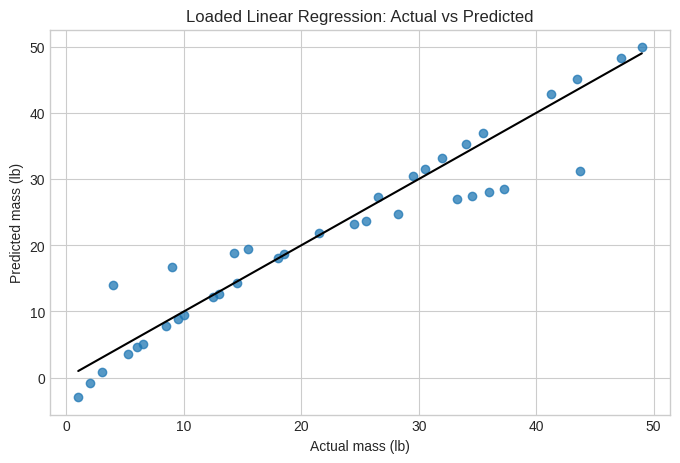

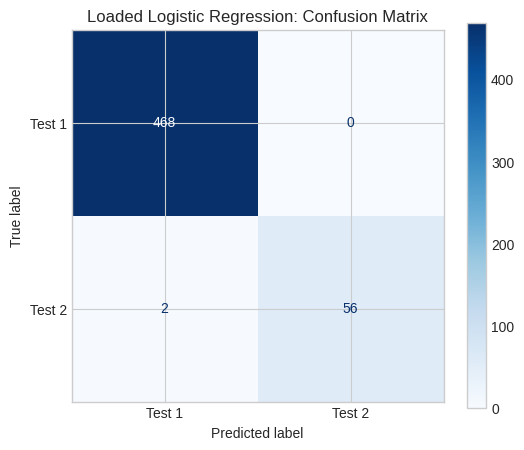

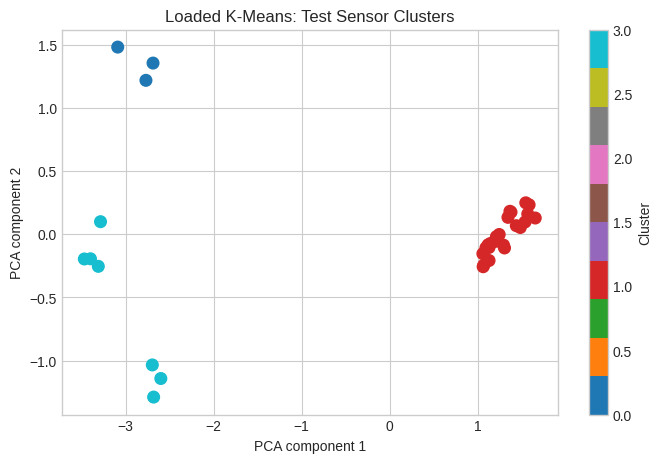

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_linear_test, linear_loaded_predictions, alpha=0.75)
ax.plot([y_linear_test.min(), y_linear_test.max()], [y_linear_test.min(), y_linear_test.max()], color='black')
ax.set_title('Loaded Linear Regression: Actual vs Predicted')
ax.set_xlabel('Actual mass (lb)')
ax.set_ylabel('Predicted mass (lb)')
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_logistic_test, logistic_loaded_predictions, cmap='Blues', ax=ax)
ax.set_title('Loaded Logistic Regression: Confusion Matrix')
plt.show()

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_kmeans_test_loaded_scaled)
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=kmeans_loaded_clusters, cmap='tab10', s=70)
ax.set_title('Loaded K-Means: Test Sensor Clusters')
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()

## 8. Confirm Models Loaded Without Retraining

In [27]:
print('Linear model loaded without retraining:', hasattr(loaded_linear_model, 'coef_'))
print('Logistic model loaded without retraining:', hasattr(loaded_logistic_model, 'classes_'))
print('K-Means model loaded without retraining:', hasattr(loaded_kmeans_model, 'cluster_centers_'))

Linear model loaded without retraining: True
Logistic model loaded without retraining: True
K-Means model loaded without retraining: True
